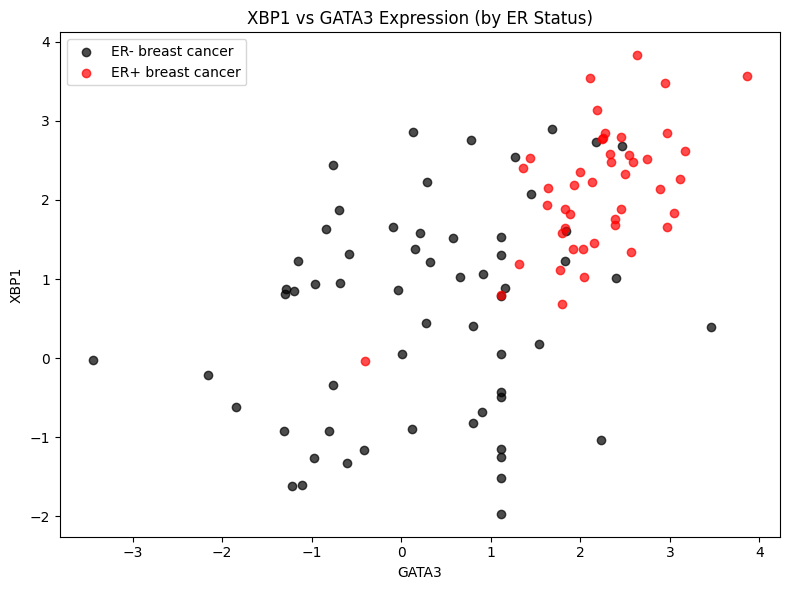

In [1]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
df = pd.read_csv('filtered.tsv.gz', sep='\t')
df1 = pd.read_csv('class.tsv', sep='\t', header=None)
columns = pd.read_csv('columns.tsv', sep='\t',comment='#')
gata3_id = columns.loc[columns['GeneSymbol'] == 'GATA3', 'ID'].values[0]
xbp1_id = columns.loc[columns['GeneSymbol'] == 'XBP1', 'ID'].values[0]
gata3_expr = df[f" {gata3_id}"]
xbp1_expr = df[f" {xbp1_id}"]
labels = df1.iloc[:, 0]

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr[labels == 0], xbp1_expr[labels == 0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_expr[labels == 1], xbp1_expr[labels == 1], color='red', alpha=0.7, label='ER+ breast cancer')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('XBP1 vs GATA3 Expression (by ER Status)')
plt.legend()
plt.tight_layout()
plt.show()


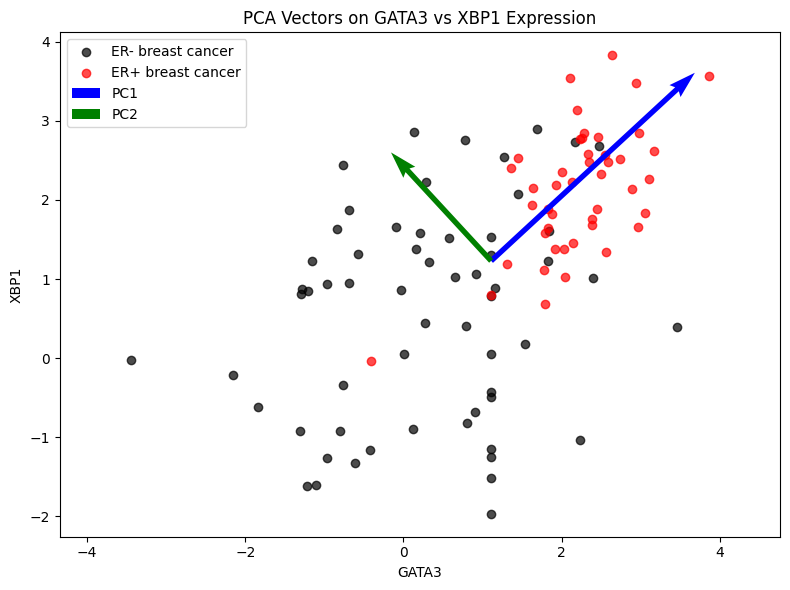

In [2]:

points = np.column_stack((gata3_expr, xbp1_expr))
mean_point = points.mean(axis=0)
centered = points - mean_point
cov = np.cov(centered.T)
eig_vals, eig_vecs = np.linalg.eig(cov)
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr[labels == 0], xbp1_expr[labels == 0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_expr[labels == 1], xbp1_expr[labels == 1], color='red', alpha=0.7, label='ER+ breast cancer')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('PCA Vectors on GATA3 vs XBP1 Expression')

for i in range(2):
    direction = eig_vecs[:, i]
    magnitude = np.sqrt(eig_vals[i]) * 2  
    plt.quiver(*mean_point, *(direction * magnitude),
               angles='xy', scale_units='xy', scale=1,
               color='blue' if i == 0 else 'green',
               label=f'PC{i+1}')

plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


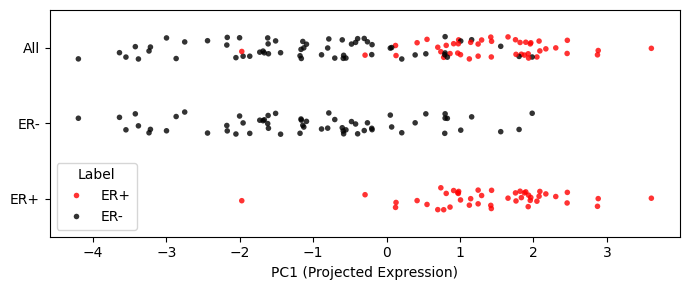

In [3]:

pc1_scores = centered @ eig_vecs[:, 0]
labels_named = labels.map({0: 'ER-', 1: 'ER+'})

pc1_df = pd.DataFrame({
    'PC1': pc1_scores,
    'Label': labels_named
})

all_group = pc1_df.copy()
all_group['Group'] = 'All'

group_er_neg = pc1_df[pc1_df['Label'] == 'ER-'].copy()
group_er_neg['Group'] = 'ER-'

group_er_pos = pc1_df[pc1_df['Label'] == 'ER+'].copy()
group_er_pos['Group'] = 'ER+'

combined_df = pd.concat([all_group, group_er_neg, group_er_pos], ignore_index=True)

plt.figure(figsize=(7, 3))
sns.stripplot(
    data=combined_df,
    x='PC1',
    y='Group',
    hue='Label',
    palette={'ER-': 'black', 'ER+': 'red'},
    dodge=False,
    jitter=0.15,
    size=4,
    alpha=0.8,
    orient='h'
)
plt.xlabel('PC1 (Projected Expression)')
plt.ylabel('')
plt.tight_layout()
plt.show()
